# 1. Introduction

This notebook is dedicated to the formal analysis of anderson acceleration applied to a symmetric and reflective PWR pin

To model this, we have made a case grid using the following:

NPG = [100k, 10k, 10k, 10k, 10k]
factors = [1.0, 1.0, 1.5, 2.0, 4.0]

For each NPG/factor combo do:
N (in $AA_N$) = [2,3,4,5,6]

Then for each of these do 20 simulations

The result is 5x5x20=500 simulations using anderson acceleration that we can analyze


## 1.1 Starting imports and functions

In [1]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend, nice_ax_legend
import matplotlib.pyplot as plt
import numpy as np
import copy
clrs = Colors.colors()
aa = Anderson().get_from_pkl('aa2_i100_t2.pkl')
aaScaling = Anderson().get_from_pkl('aa2_scaling1.5_1step.pkl')
aaScaling2 = Anderson().get_from_pkl('aa2_i11_t2_2x.pkl')


from CustomSchemes.DumbTransport import flat_transport


def get_norm(x: np.ndarray, xref: np.ndarray, order: int = 2) -> float:
  """gets the norm with the given order (default 2)"""
  return (np.linalg.norm(x - xref, ord=order)/np.linalg.norm(x, ord=order))

def get_all_norms_prev(x: list[np.ndarray], **kwargs):
  """get norms using previous solution"""
  resids_x = []
  npg = 0
  solve_np = 100000*500 # number active particles in each iteration
  x_old = x[0]
  x = x[1:]
  while len(x) > 0:
    resids_x.append(get_norm(x=x[0], xref=x_old))
    x_old = x[0]
    x = x[1:]
  return resids_x

def get_all_norms(x: list[np.ndarray], ref: np.ndarray):
  """get norms using a known reference solution"""
  resids_x = []
  npg = 0
  solve_np=100000*500
  total_histories = []
  for idx, this in enumerate(x):
    resids_x.append(get_norm(this, ref))
    total_histories.append(npg)
    try:
      npg+=solve_np
    except:
      npg += 0
  return resids_x

def particles_from_npg(time: float, aa: Anderson, nactive: int):
  """gets cumulative particles from NPG variable"""
  # for anderson, the first x() soln is always the predictor, which requires no NPG to get
  assert isinstance(aa, Anderson), "aa is not type Anderson"
  npg = 0
  npgvec = aa._npg[time]
  assert npgvec is not None, "npg vec is None, "
  new = [npg]
  for this in npgvec:
    new.append(new[-1] + this*nactive)

  assert len(new) == len(aa.x[time])
  return new

def particles_from_steps(time: float, aa: Anderson | SIE, nactive: int, npg: int):
  """used when you have a constant particles per step (not increasing hisstories withn more iterates)"""
  if isinstance(aa, Anderson):
    return _aa_particles_from_steps(time=time, aa=aa, nactive=nactive, npg=npg)
  elif isinstance(aa, SIE):
    return _sie_particles_from_steps(time=time, sie=aa, nactive=nactive, npg=npg)
  else:
    raise Exception("Not Anderson or SIE -- we dont know what to do!")

def _aa_particles_from_steps(time: float, aa: Anderson, nactive: int, npg: int):
  """aa uses x[0] as the predictor which means no particles are required"""
  return np.linspace(0,npg*nactive*(len(aa.x[time])-1), len(aa.x[time]))

def _sie_particles_from_steps(time: float, sie: SIE, nactive: int, npg: int):
  """sie uses x[0] as an actual solve, so we start at a nonzero number"""
  return np.linspace(npg*nactive,npg*nactive*(len(sie.x[time])), len(sie.x[time]))

def get_the_max(norms: list[np.ndarray]):
  """gets the max norm given a list of norm vectors"""
  the_max = copy.deepcopy(norms[0])
  for idx, _ in enumerate(the_max):
    for norm in norms:
      if norm[idx] > the_max[idx]:
        the_max[idx] = norm[idx]

  return the_max

def get_the_min(norms: list[np.ndarray]):
  """gets the max norm given a list of norm vectors"""
  the_max = copy.deepcopy(norms[0])
  for idx, _ in enumerate(the_max):
    for norm in norms:
      if norm[idx] < the_max[idx]:
        the_max[idx] = norm[idx]

  return the_max

def get_the_average(norms: list[np.ndarray]):
  """gets the average norm vs. iteration from a list of norm arrays"""
  the_max = np.zeros(len(norms[0]))
  for norm in norms:
    the_max += np.array(norm)
  the_max /= len(norms)
  return the_max

def get_aa_norm_average(order: int, factor: int, npg: int) -> tuple[list[int], np.ndarray[tuple[int], float]]:
  """gets the aa norm average across a number of simulations for a given:
  order and factor f"""
  norm_list = []
  for s in range(1,21):
    try:
      aa = Anderson().get_from_pkl(f'{folder}/aa{order}_f{factor}_s{s}_npg{npg}.pkl')
    except:
      continue
    parts = particles_from_npg(time=time, aa=aa, nactive=nactive) # getting particles from np
    norms = get_all_norms(x=aa.x[time], ref=flat_transport(16)) # norms against reference
    norm_list.append(norms)
  return parts, get_the_average(norm_list)

def get_sie_results_average(npg: int, niter: int, nactive: int, time: float | int):
  """gets the average of all 20x sie results for a given npg and niter case"""
  all_norms = []
  for s in range(1,21):
    try:
      sie = SIE().get_from_pkl(f'results/SIE_SWEEP_RESULTS/sie_s{s}_npg{npg}_i{niter}.pkl')
    except:
      continue
    parts = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)
    norms = get_all_norms(x=sie.x[time], ref=flat_transport(16))
    all_norms.append(norms)
  the_mean_norms = get_the_average(all_norms)
  return parts, the_mean_norms

def get_sie_results_all(npg: int, niter: int, nactive: int, time: float | int):
  """get all of the sie results norms
  
  Returns
  =======
  number of particles [1D array]

  a list of norms [list of np arrays]
  """
  all_norms = []
  for s in range(1,21):
    try:
      sie = SIE().get_from_pkl(f'results/SIE_SWEEP_RESULTS/sie_s{s}_npg{npg}_i{niter}.pkl')
    except:
      continue
    parts = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)
    norms = get_all_norms(x=sie.x[time], ref=flat_transport(16))
    all_norms.append(norms)
  return parts, all_norms

## 1.2. Defaults

In [2]:
# Simulation information
nactive = 500
time = 325

# File information
npg = 10000
# s = 15
f = 4.0
# aaOrder = 2
folder = 'results/AA_SWEEP_RESULTS'

dpi = 100

# 2. $AA_N$ with constant NPG

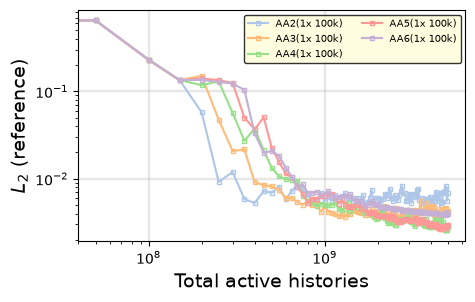

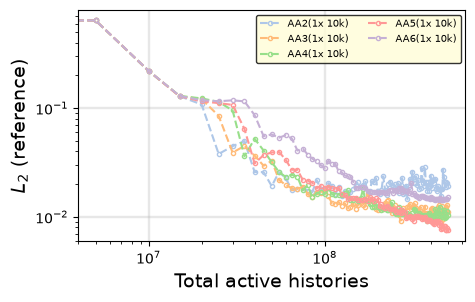

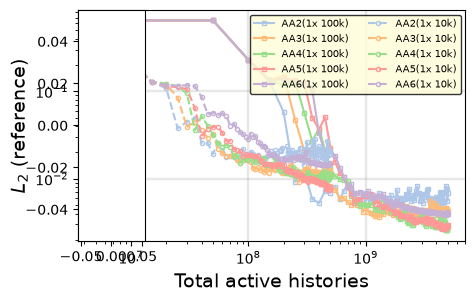

In [19]:
"""get the averages of AA2 (1x 10000) and plot them"""
plt.figure(figsize=(5,3), dpi=dpi)
idx = -1
for order in [2,3,4,5,6]:
  idx += 1
  parts100k, norm_avg_all_steps100k = get_aa_norm_average(order=order, factor=1, npg=100000)
  plt.plot(parts100k, norm_avg_all_steps100k, 's-', color=clrs[idx], alpha=1.0, markerfacecolor='none', label=f'AA{order}({1}x 100k)', ms=3)
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (reference)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)


"""get the averages of AA2 (1x 100000) and plot them"""
plt.figure(figsize=(5,3), dpi=dpi)
idx = -1
for order in [2,3,4,5,6]:
  idx += 1
  parts100k, norm_avg_all_steps100k = get_aa_norm_average(order=order, factor=1, npg=10000)
  plt.plot(parts100k, norm_avg_all_steps100k, 'o--', color=clrs[idx], alpha=1.0, markerfacecolor='none', label=f'AA{order}({1}x 10k)', ms=3)
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (reference)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)

"""get the averages of AA2 (1x 10000) and plot them"""
plt.figure(figsize=(5,3), dpi=dpi)
idx = -1
for order in [2,3,4,5,6]:
  idx += 1
  parts100k, norm_avg_all_steps100k = get_aa_norm_average(order=order, factor=1, npg=100000)
  plt.plot(parts100k, norm_avg_all_steps100k, 's-', color=clrs[idx], alpha=1.0, markerfacecolor='none', label=f'AA{order}({1}x 100k)', ms=3)
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (reference)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)

# plt.figure(figsize=(5,3), dpi=dpi)
idx = -1
for order in [2,3,4,5,6]:
  idx += 1
  parts100k, norm_avg_all_steps100k = get_aa_norm_average(order=order, factor=1, npg=10000)
  plt.plot(parts100k, norm_avg_all_steps100k, 'o--', color=clrs[idx], alpha=1.0, markerfacecolor='none', label=f'AA{order}({1}x 10k)', ms=3)
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (reference)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)

"""Plot 5 graphs - each with all the lines as black lines"""
axes = plt.subplot(1,5,1)
idx = 0
for s in range(1,21):
  aa = Anderson().get_from_pkl(f'{folder}/aa{order}_f{1}_s{s}_npg{10000}.pkl')
  all_norms = []
  for order in [2,3,4,5,6]:
    parts = particles_from_npg(time=time, aa=aa, nactive=nactive) # getting particles from np
    norms = get_all_norms(x=aa.x[time], ref=flat_transport(16)) # norms against reference
    all_norms.append(norms)
  plt.plot()


# 3. $AA_N$ with variable NPG (10k starting NPG)

## 3.1 Variable multiplier ($f$) for different N values for $AA_N$

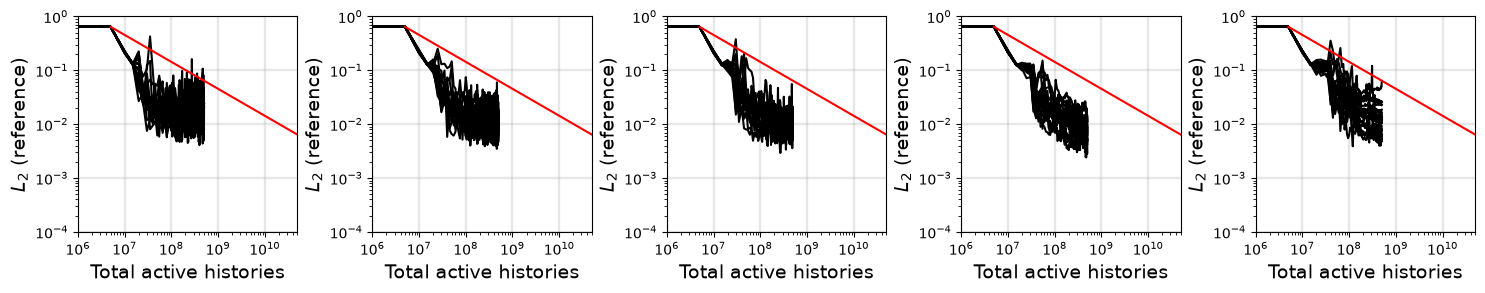

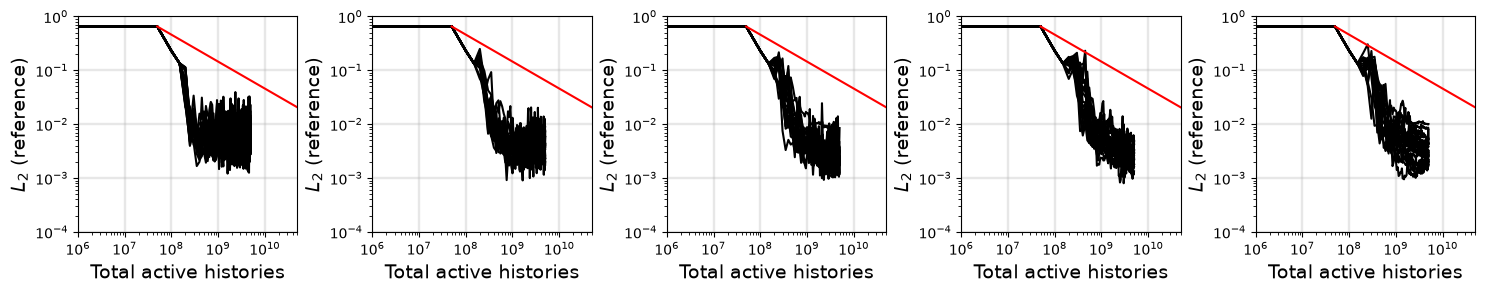

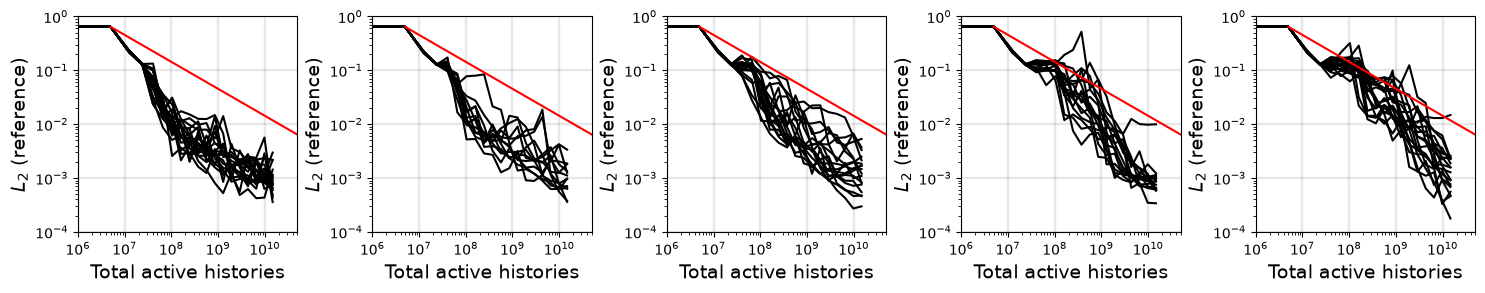

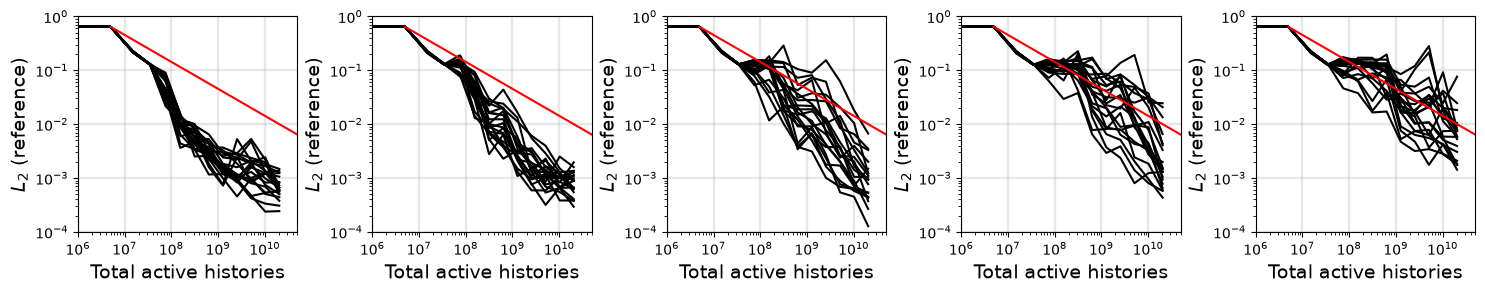

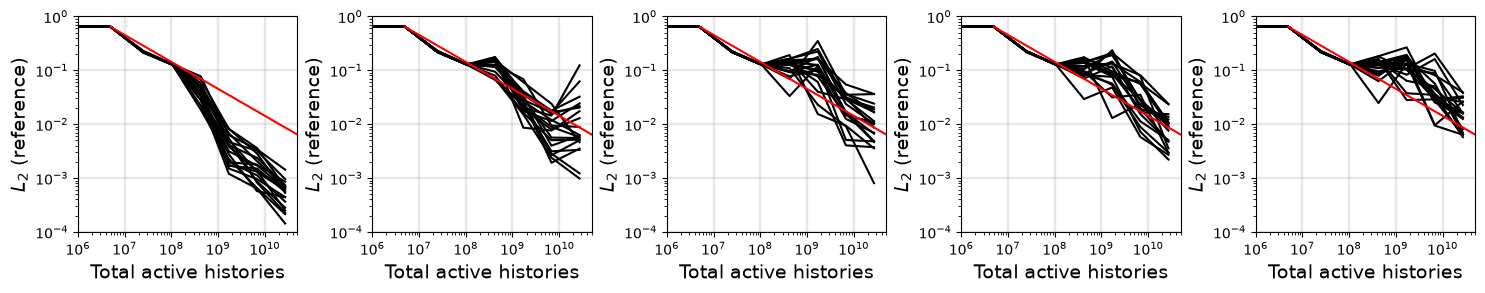

In [52]:
def plot_subplots_factor_npg(factor: float , npg: int):
  """plots set of 5 plots for a given factor and an npg"""
  # factor = 1.0
  # npg = 10000
  fig, axes = plt.subplots(1,5, figsize=(15,3))
  plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
  ylims = [1e-4, 1]
  xlims = [1e6, 5e10]


  for idx, order in enumerate([2,3,4,5,6]):
    ax = axes[idx]
    for s in range(1,21):
      try:
        aa = Anderson().get_from_pkl(f'{folder}/aa{order}_f{factor}_s{s}_npg{npg}.pkl')
      except:
        continue
      parts = particles_from_npg(time=time, aa=aa, nactive=nactive) # getting particles from np
      norms = get_all_norms(x=aa.x[time], ref=flat_transport(16)) # norms against reference
      ax.plot(parts, norms, 'k-')

      
      ax.set_yscale('log')
      ax.set_xscale('log')
      ax.grid(lw=1.7, alpha=0.3)
      # nice_grid()
      # nice_legend(ncols=2, fontsize=7)
      ax.set_ylabel(r'$L_2$ (reference)', fontsize=14)
      ax.set_xlabel(r'Total active histories', fontsize=14)
      ax.set_ylim(ylims)
      ax.set_xlim(xlims)

    # SQRT(N) line
    x = np.linspace(parts[1], 1e11, 1000)
    y = norms[1] / np.sqrt(x) * np.sqrt(x[0])
    ax.plot(x,y, 'r-', label='SQRT(N)')


plot_subplots_factor_npg(factor=1, npg=10000)
plot_subplots_factor_npg(factor=1, npg=100000)
plot_subplots_factor_npg(factor=1.5, npg=10000)
plot_subplots_factor_npg(factor=2.0, npg=10000)
plot_subplots_factor_npg(factor=4.0, npg=10000)

In [24]:
f'{folder}/aa{order}_f{factor}_s{s}_npg{npg}.pkl'

'results/AA_SWEEP_RESULTS/aa6_f2_s20_npg10000.pkl'

# 3.2 SIE results comparison

## Compare SIE results for different NPG and number of iterations, but the same total number of active histories

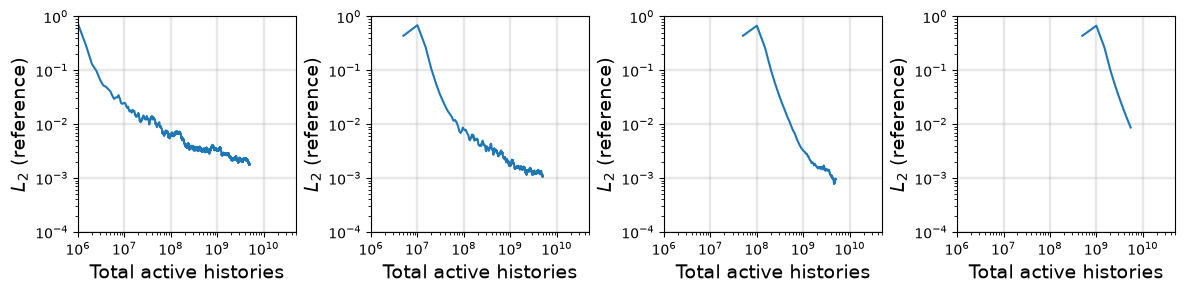

In [17]:
fig, axes = plt.subplots(1,4, figsize=(12,3))
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
ylims = [1e-4, 1]
xlims = [1e6, 5e10]

npgs = [1000, 10000, 100000, 1000000]
niter = [10000, 1000, 100, 10]

for idx, _ in enumerate(npgs):
  sie_x, sie_y = get_sie_results_average(npg=npgs[idx], niter=niter[idx], nactive=nactive, time=time)
  sie_x, norm_list = get_sie_results_all(npg=npgs[idx], niter=niter[idx], nactive=nactive, time=time)

  ax = axes[idx]
  ax.plot(sie_x, sie_y)

  ax.set_yscale('log')
  ax.set_xscale('log')
  ax.grid(lw=1.7, alpha=0.3)
  # nice_grid()
  # nice_legend(ncols=2, fontsize=7)
  ax.set_ylabel(r'$L_2$ (reference)', fontsize=14)
  ax.set_xlabel(r'Total active histories', fontsize=14)
  ax.set_ylim(ylims)
  ax.set_xlim(xlims)

In [18]:
# Fetching the data of each case
npgs = [1000, 10000, 100000, 1000000]
niter = [10000, 1000, 100, 10]
the_dict = {}
for idx, _ in enumerate(npgs):
  # sie_x, sie_y = get_sie_results_average(npg=npgs[idx], niter=niter[idx], nactive=nactive, time=time)
  sie_x, sie_y = get_sie_results_all(npg=npgs[idx], niter=niter[idx], nactive=nactive, time=time)
  the_dict[npgs[idx]] = [sie_x, sie_y]


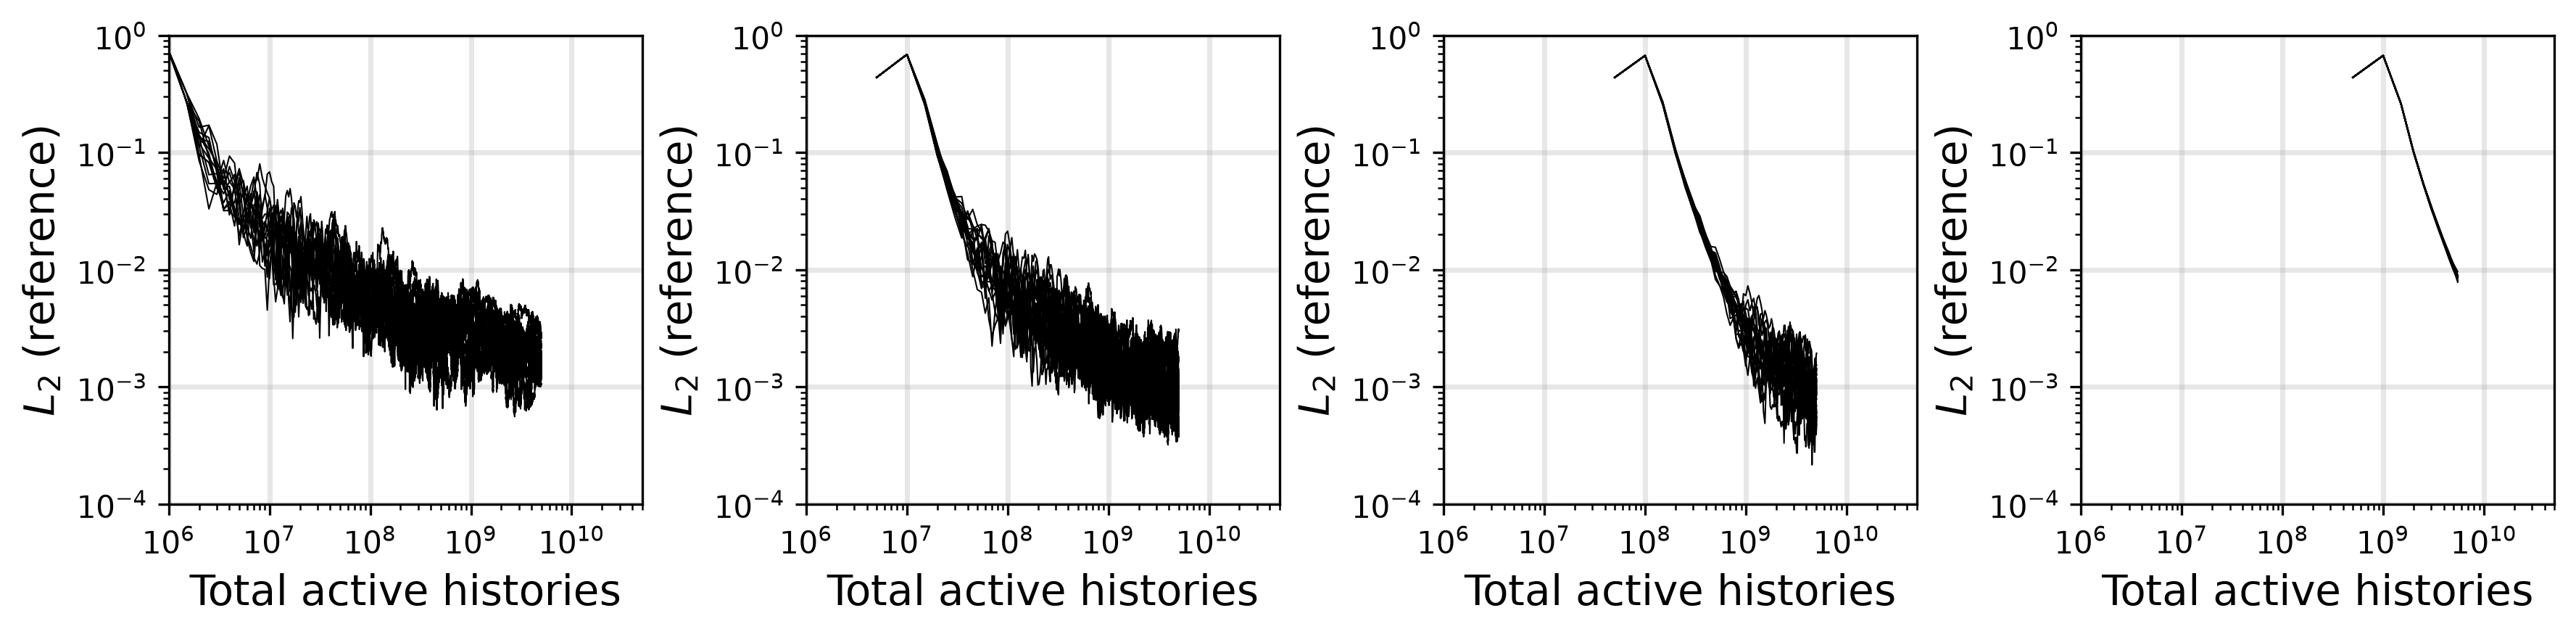

In [19]:
fig, axes = plt.subplots(1,4, figsize=(12,3), dpi=300)
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
ylims = [1e-4, 1]
xlims = [1e6, 5e10]

idx = -1
for npg in the_dict.keys():
  sie_x = the_dict[npg][0]
  sie_y = the_dict[npg][1]
  idx += 1
  ax = axes[idx]
  for y in sie_y:
    ax.plot(sie_x, y, 'k-', lw=0.5)

  ax.set_yscale('log')
  ax.set_xscale('log')
  ax.grid(lw=1.7, alpha=0.3)
  # nice_grid()
  # nice_legend(ncols=2, fontsize=7)
  ax.set_ylabel(r'$L_2$ (reference)', fontsize=14)
  ax.set_xlabel(r'Total active histories', fontsize=14)
  ax.set_ylim(ylims)
  ax.set_xlim(xlims)

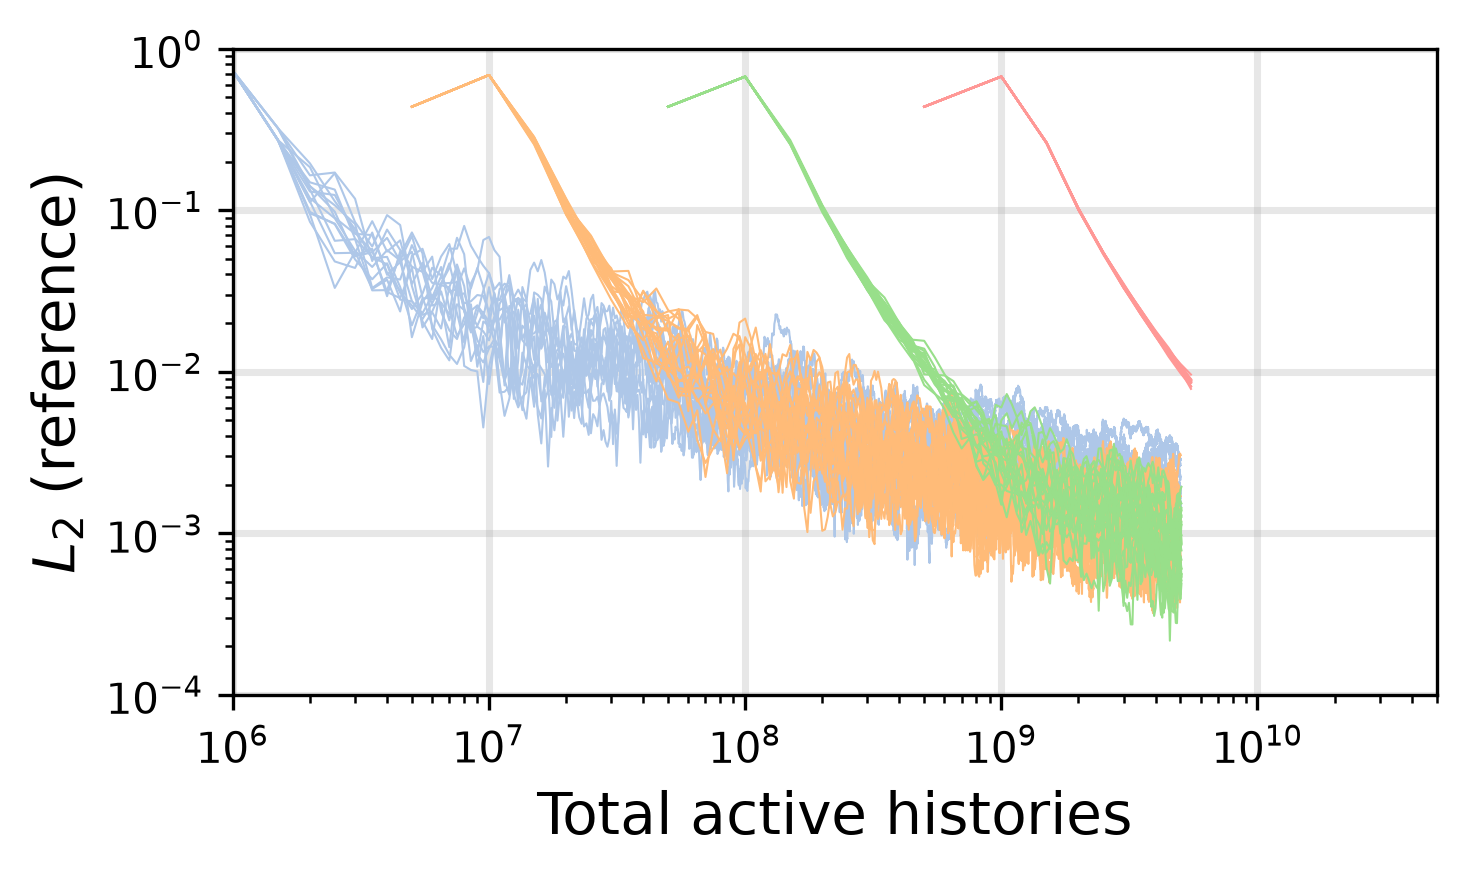

In [20]:
fig, axes = plt.subplots(1,1, figsize=(5,3), dpi=300)
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
ylims = [1e-4, 1]
xlims = [1e6, 5e10]
idx = -1
for npg in the_dict.keys():
  sie_x = the_dict[npg][0]
  sie_y = the_dict[npg][1]
  idx += 1
  ax = axes
  for y in sie_y:
    ax.plot(sie_x, y, '-', lw=0.5, color=clrs[idx])

  ax.set_yscale('log')
  ax.set_xscale('log')
  ax.grid(lw=1.7, alpha=0.3)
  # nice_grid()
  # nice_legend(ncols=2, fontsize=7)
  ax.set_ylabel(r'$L_2$ (reference)', fontsize=14)
  ax.set_xlabel(r'Total active histories', fontsize=14)
  ax.set_ylim(ylims)
  ax.set_xlim(xlims)

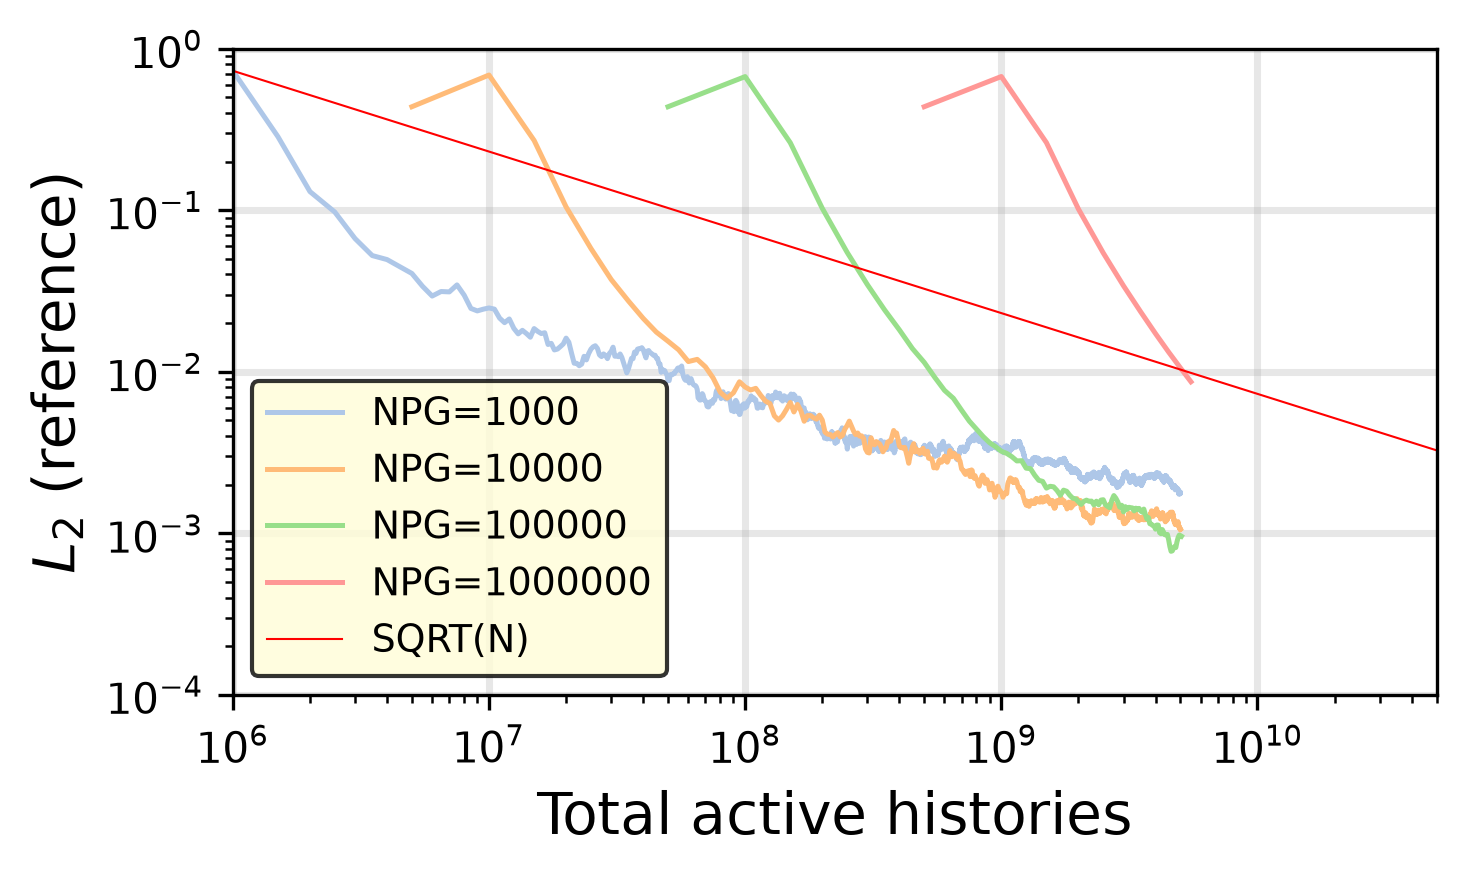

In [21]:
fig, axes = plt.subplots(1,1, figsize=(5,3), dpi=300)
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
ylims = [1e-4, 1]
xlims = [1e6, 5e10]
idx = -1
for npg in the_dict.keys():
  sie_x = the_dict[npg][0]
  sie_y = the_dict[npg][1]

  the_avg = get_the_average(sie_y)
  idx += 1
  ax = axes
  ax.plot(sie_x, the_avg, '-', lw=1.2, color=clrs[idx], label=f'NPG={npg}')

  ax.set_yscale('log')
  ax.set_xscale('log')
  ax.grid(lw=1.7, alpha=0.3)
  # nice_grid()
  # nice_legend(ncols=2, fontsize=7)
  ax.set_ylabel(r'$L_2$ (reference)', fontsize=14)
  ax.set_xlabel(r'Total active histories', fontsize=14)
  ax.set_ylim(ylims)
  ax.set_xlim(xlims)
  

  # SQRT(N) line
  if npg == list(the_dict.keys())[0]:
    x = np.linspace(sie_x[1], 1e11, 1000)
    y = sie_y[0][1] / np.sqrt(x) * np.sqrt(x[0])
ax.plot(x,y, 'r-', label='SQRT(N)', lw=0.5)
nice_ax_legend(ax=ax, fontsize=9)